In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [2]:
covid = pd.read_csv("compact.csv", sep=None, engine='python')

In [3]:
covid.drop(columns=[ 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'excess_mortality',
 'excess_mortality_cumulative',
 'excess_mortality_cumulative_absolute',
 'excess_mortality_cumulative_per_million',
 'hosp_patients',
 'hosp_patients_per_million',
 'weekly_hosp_admissions',
 'weekly_hosp_admissions_per_million',
 'icu_patients',
 'icu_patients_per_million','weekly_icu_admissions_per_million',
 'stringency_index',
 'reproduction_rate',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'total_boosters_per_hundred',
 'new_vaccinations_smoothed_per_million',
 'new_people_vaccinated_smoothed',
 'new_people_vaccinated_smoothed_per_hundred','weekly_icu_admissions', 'new_deaths_smoothed', 'new_cases_per_million',
 'new_cases_smoothed_per_million', 'new_cases_smoothed'], inplace=True)

In [4]:
covid.columns.tolist()

['country',
 'date',
 'total_cases',
 'new_cases',
 'total_cases_per_million',
 'total_deaths',
 'new_deaths',
 'total_deaths_per_million',
 'code',
 'continent',
 'population',
 'population_density',
 'median_age',
 'life_expectancy',
 'gdp_per_capita',
 'extreme_poverty',
 'diabetes_prevalence',
 'handwashing_facilities',
 'hospital_beds_per_thousand',
 'human_development_index']

In [5]:
countries = [
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Antigua and Barbuda",
    "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain",
    "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bhutan",
    "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria",
    "Burkina Faso", "Burundi", "Cabo Verde", "Cambodia", "Cameroon", "Canada",
    "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros",
    "Congo", "Costa Rica", "Croatia", "Cuba", "Cyprus", "Czech Republic", "Denmark",
    "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "El Salvador",
    "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Fiji",
    "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece",
    "Grenada", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras",
    "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel",
    "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya", "Kiribati",
    "Kuwait", "Kyrgyzstan", "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia",
    "Libya", "Liechtenstein", "Lithuania", "Luxembourg", "Madagascar", "Malawi",
    "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania",
    "Mauritius", "Mexico", "Micronesia", "Moldova", "Monaco", "Mongolia",
    "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal",
    "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Korea",
    "North Macedonia", "Norway", "Oman", "Pakistan", "Palau", "Palestine", "Panama",
    "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland", "Portugal",
    "Qatar", "Romania", "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia",
    "Saint Vincent and the Grenadines", "Samoa", "San Marino", "Sao Tome and Principe",
    "Saudi Arabia", "Senegal", "Serbia", "Seychelles", "Sierra Leone", "Singapore",
    "Slovakia", "Slovenia", "Solomon Islands", "Somalia", "South Africa", "South Korea",
    "South Sudan", "Spain", "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland",
    "Syria", "Taiwan", "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo",
    "Tonga", "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", "United States",
    "Uruguay", "Uzbekistan", "Vanuatu", "Vatican City", "Venezuela", "Vietnam",
    "Yemen", "Zambia", "Zimbabwe", "World"
]

In [6]:
a = covid.groupby(["continent"]).sum()
col = a.index.tolist()
covid = covid[covid["country"].isin(countries)]

In [7]:
covid = covid.bfill(axis=0).fillna(0)
covid["total_cases"] = covid.total_cases.apply(lambda p: int(p))
covid["total_deaths"] = covid.total_deaths.apply(lambda p: int(p))

In [8]:
total_cases = covid.groupby(["country"]).total_cases.sum()
total_deaths = covid.groupby(["country"]).total_deaths.sum()
# Which countries had the most cases?
countries_most_cases = total_cases.sort_values(ascending=False)
# Which countries had the most deaths?
countries_most_deaths = total_deaths.sort_values(ascending=False)

In [54]:
covid['date'] = pd.to_datetime(covid['date'], format="%m/%d/%y")

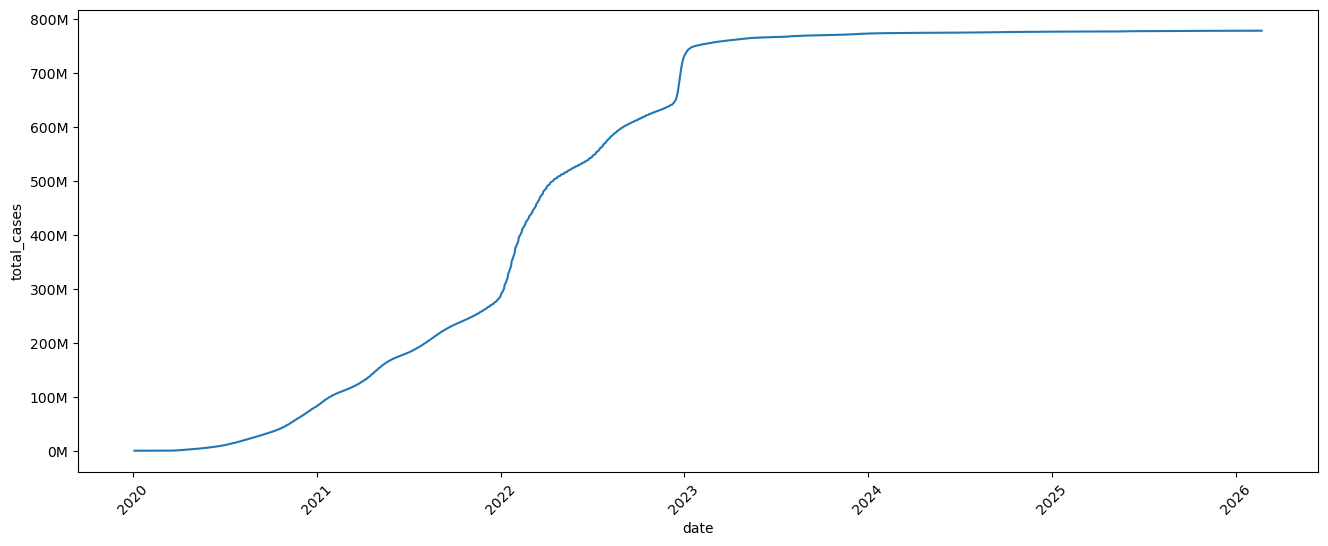

In [67]:
# Total Cases Line Plot
plt.figure(figsize=(16, 6))
data=covid[covid["country"] == "World"]
sns.lineplot(x=covid["date"],y=data["total_cases"])
plt.title("Global COVID-19 Total Cases Over Time", fontsize=16)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
plt.xticks(rotation=45)
plt.show()

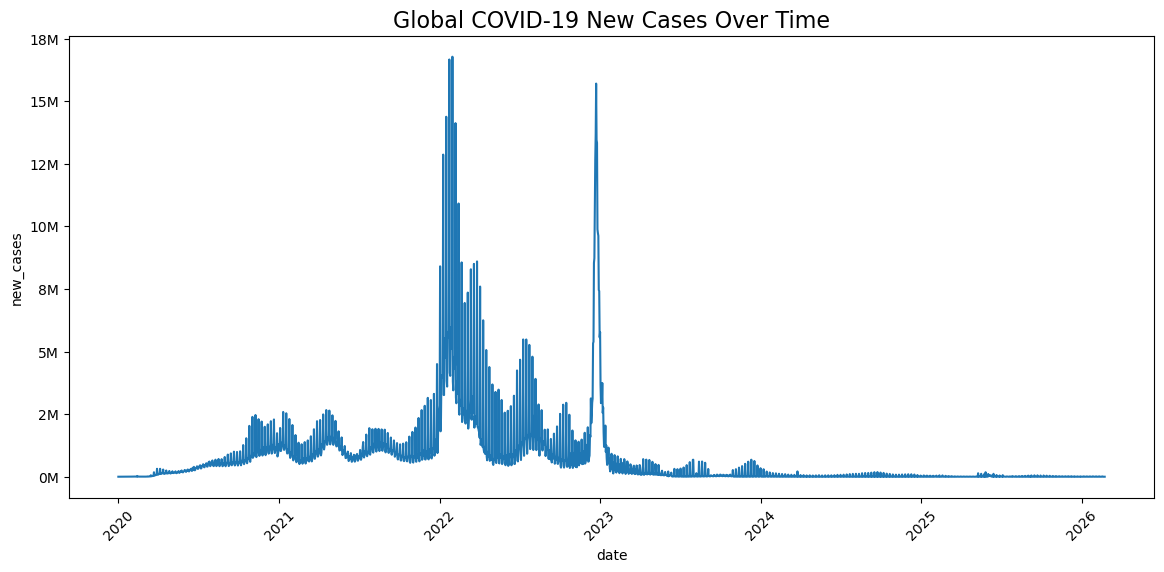

In [127]:
# New Cases Line Plot
plt.figure(figsize=(14, 6))
data=covid.groupby(["date"])
new_cases = data["new_cases"].sum()

sns.lineplot(new_cases)
plt.title("Global COVID-19 New Cases Over Time", fontsize=16)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
plt.xticks(rotation=45)
plt.show()

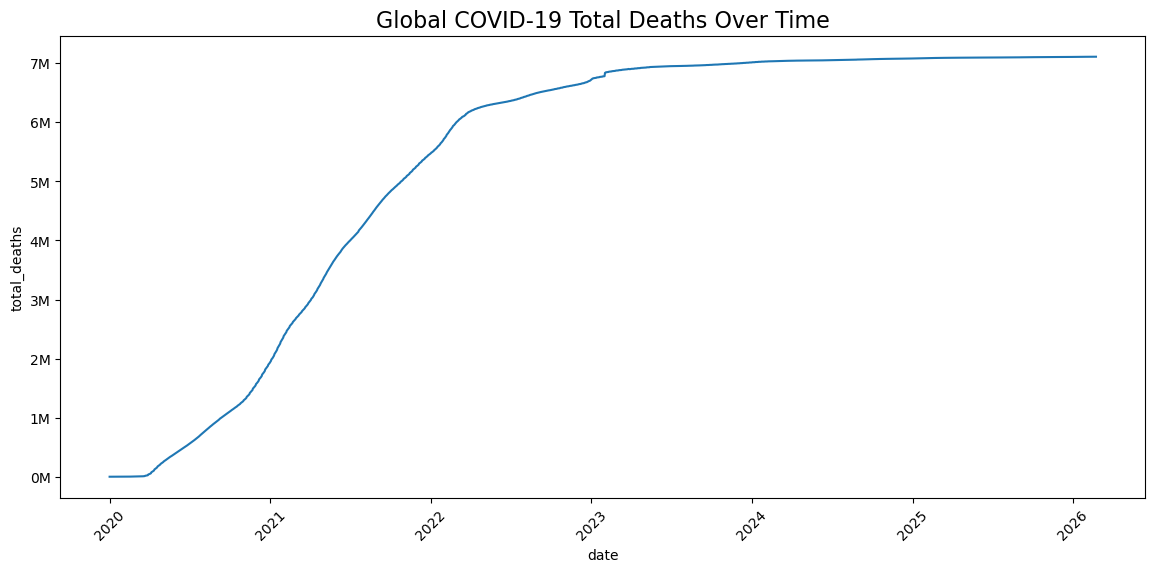

In [125]:
plt.figure(figsize=(14, 6))
deaths = data["total_deaths"].max()
sns.lineplot(deaths)
plt.title("Global COVID-19 Total Deaths Over Time", fontsize=16)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
plt.xticks(rotation=45)
plt.show()

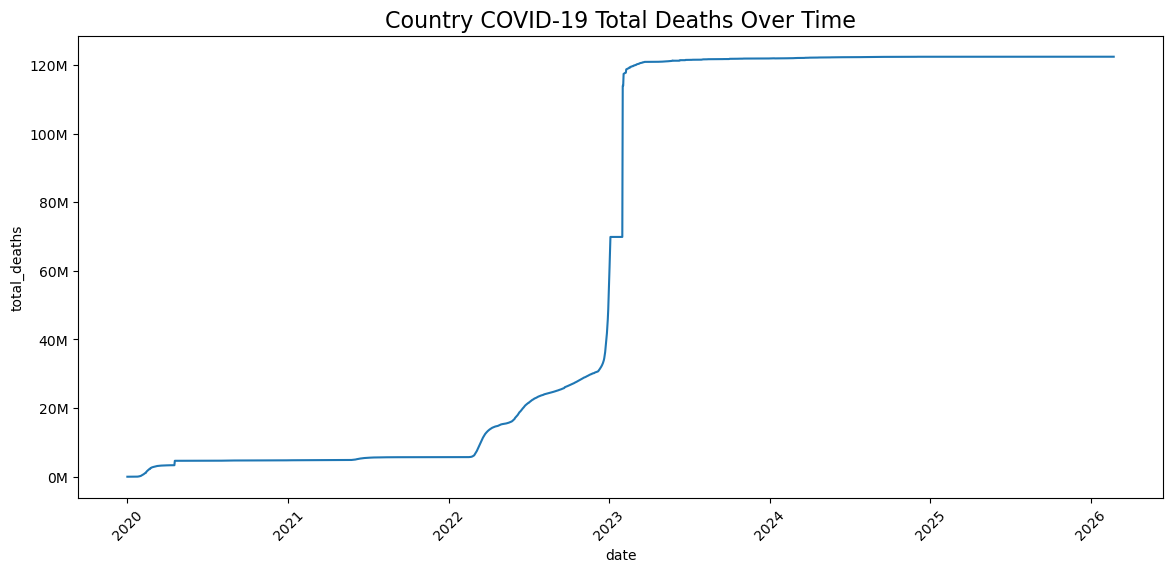

In [118]:
plt.figure(figsize=(14, 6))
country = covid[covid["country"] == "China"].groupby("date")["total_deaths"].max()
sns.lineplot(country)
plt.title("Country COVID-19 Total Deaths Over Time", fontsize=16)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:.0f}M"))
plt.xticks(rotation=45)
plt.show()